# Tarea 1 - Análisis de Rendimiento y Riesgo de Activos Financieros

**Materia:** Portafolios de Inversión  
**Activos analizados:** PRGO, PLTR y BRK-B  
**Periodo de análisis:** 01/01/2018 - 24/08/2026

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
prgo = yf.Ticker("PRGO")
pltr = yf.Ticker("PLTR")
brk = yf.Ticker("BRK-B")

## 1. Investigación de las emisoras

### PRGO - Perrigo Company plc

#### ¿A qué se dedica?

Fabricante de medicamentos genéricos de venta libre con sede en Irlanda. Su modelo principal es la producción de marca blanca (store brand) para cadenas minoristas y tiendas de conveniencia, además de algunas marcas propias.


#### Sector económico según GICS

Health Care. Aunque su negocio se parece al consumo masivo por el canal de venta, sus productos son medicamentos sujetos a regulación sanitaria dentro de la categoría de autocuidado de la salud, lo que determina la clasificación.


#### Principales competidores

Kenvue, Haleon, Bayer Consumer Health y Procter & Gamble, entre otros. Todas compiten con Perrigo en medicamentos de autocuidado, y varias también fabrican marca blanca. Perrigo es la más pequeña por valor de mercado, pero es líder absoluta en marca blanca; las demás diversifican mucho más su modelo de negocio y dependen de marcas propias con mayor poder de precio.


#### Estado de Resultados

**Cifras en millones de dólares**

In [19]:
estado_resultados_prgo = prgo.financials.loc[
    [
        'Total Revenue',
        'Gross Profit',
        'Operating Income',
        'EBITDA',
        'Interest Expense',
        'Pretax Income',
        'Net Income'
    ]
].iloc[:, :4] / 1_000_000

estado_resultados_prgo

,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Total Revenue,4253.1,4373.4,4655.6,4451.6
Gross Profit,1494.5,1542.7,1680.4,1455.4
Operating Income,312.8,311.9,284.1,121.4
EBITDA,-797.9,433.0,525.0,355.5
Interest Expense,162.5,187.8,173.8,156.0
Pretax Income,-1297.9,-80.7,-8.3,-139.1
Net Income,-1425.4,-171.8,-12.7,-140.6


Los ingresos de Perrigo disminuyeron de 4,655.6 millones en 2023 a 4,253.1 millones en 2025. La utilidad operativa se mantuvo positiva, pero la utilidad antes de impuestos y la utilidad neta fueron negativas, especialmente en 2025, cuando la pérdida neta fue de 1,425.4 millones. Esto muestra que, aunque la empresa sigue generando ingresos y utilidad operativa, al final está registrando pérdidas importantes.


#### Balance General

**Cifras en millones de dólares**

In [20]:
balance_prgo = prgo.balance_sheet.loc[
    [
        'Total Assets',
        'Cash And Cash Equivalents',
        'Accounts Receivable',
        'Inventory',
        'Total Liabilities Net Minority Interest',
        'Total Debt',
        'Stockholders Equity',
        'Working Capital'
    ]
].iloc[:, :4] / 1_000_000

balance_prgo

,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Total Assets,8535.2,9647.7,10809.1,11017.3
Cash And Cash Equivalents,531.6,558.8,751.3,600.7
Accounts Receivable,612.8,642.3,739.6,697.1
Inventory,1149.0,1081.8,1140.9,1150.3
Total Liabilities Net Minority Interest,5599.7,5328.3,6041.2,6175.2
Total Debt,3640.2,3618.1,4073.4,4106.6
Stockholders Equity,2935.5,4319.4,4767.9,4842.1
Working Capital,1784.5,1437.7,1246.6,1606.3


Los activos totales de Perrigo disminuyeron en los últimos años, pasando de 11,017.3 millones en 2022 a 8,535.2 millones en 2025. Aunque la deuda total también disminuyó, el capital contable presentó una caída importante hasta 2,935.5 millones. Sin embargo, el capital de trabajo se mantiene positivo, lo que indica que la empresa todavía conserva una posición de liquidez favorable en el corto plazo.

#### Flujo de Efectivo


In [21]:
flujo_prgo = prgo.cashflow.loc[
    [
        'Operating Cash Flow',
        'Capital Expenditure',
        'Free Cash Flow',
        'Investing Cash Flow',
        'Financing Cash Flow',
        'Repayment Of Debt',
        'Cash Dividends Paid'
    ]
].iloc[:, :4] / 1_000_000

flujo_prgo

,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Operating Cash Flow,238.5,362.9,405.5,307.3
Capital Expenditure,-93.4,-118.3,-101.7,-96.4
Free Cash Flow,145.1,244.6,303.8,210.9
Investing Cash Flow,-75.4,78.8,-77.5,-1958.6
Financing Cash Flow,-220.5,-611.0,-187.2,421.6
Repayment Of Debt,-34.8,-1529.0,-325.3,-970.6
Cash Dividends Paid,-159.3,-152.5,-149.7,-142.4


El flujo de efectivo operativo de Perrigo disminuyó de 405.5 millones en 2023 a 238.5 millones en 2025, lo que muestra una menor generación de efectivo por sus operaciones. El flujo de caja libre también bajó de 303.8 millones en 2023 a 145.1 millones en 2025. A pesar de esto, la empresa sigue generando flujo de caja libre positivo. En 2025 también realizó pagos de dividendos por 159.3 millones y pagos de deuda por 34.8 millones.


### PLTR - Palantir Technologies Inc.

#### ¿A qué se dedica?

Desarrolla plataformas de software para integrar, analizar y operar sobre grandes volúmenes de datos. Sus productos son Gotham (defensa e inteligencia), Foundry (empresas) y AIP (capa de inteligencia artificial). Vende mediante contratos plurianuales a gobiernos y grandes corporativos; el negocio se reparte casi por mitades entre gobierno (3.211) y comercial (2.945).


#### Sector económico según GICS

Information Technology — Software & Services. Aunque buena parte de sus ingresos viene de defensa, no fabrica hardware ni armamento: vende licencias de software, por lo que no clasifica en Industrials.


#### Principales competidores

Snowflake, Databricks, Microsoft (Azure/Fabric), IBM y Booz Allen Hamilton en el segmento gubernamental. La diferencia está en el modelo: Palantir no vende únicamente la herramienta, sino el despliegue con ingenieros propios (forward-deployed engineers), lo que le da márgenes altos pero un escalamiento más lento y dependencia de pocos clientes grandes.


#### Estado de Resultados

**Cifras en millones de dólares**

In [22]:
estado_resultados_pltr = pltr.financials.loc[
    [
        'Total Revenue',
        'Gross Profit',
        'Operating Income',
        'EBITDA',
        'Interest Expense',
        'Pretax Income',
        'Net Income'
    ]
].iloc[:, :4] / 1_000_000

estado_resultados_pltr

,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Total Revenue,4475.446,2865.507,2225.012,1905.871
Gross Profit,3686.269,2299.517,1793.907,1497.322
Operating Income,1414.015,310.403,119.966,-161.201
EBITDA,1440.160,341.990,153.320,-138.679
Interest Expense,NaN,NaN,3.470,4.058
Pretax Income,1657.368,489.173,237.091,-361.027
Net Income,1625.033,462.190,209.825,-373.705


Los ingresos de Palantir aumentaron de 1,905.9 millones en 2022 a 4,475.4 millones en 2025. También se observa una mejora importante en la utilidad operativa, que pasó de ser negativa en 2022 a 1,414.0 millones en 2025. La utilidad neta siguió la misma tendencia, pasando de una pérdida de 373.7 millones en 2022 a una ganancia de 1,625.0 millones en 2025. Esto muestra que la empresa no solo ha incrementado sus ingresos, sino que también ha mejorado de forma importante su rentabilidad.


#### Balance General

**Cifras en millones de dólares**

In [23]:
balance_pltr = pltr.balance_sheet.loc[
    [
        'Total Assets',
        'Cash And Cash Equivalents',
        'Cash Cash Equivalents And Short Term Investments',
        'Accounts Receivable',
        'Total Liabilities Net Minority Interest',
        'Total Debt',
        'Stockholders Equity',
        'Working Capital'
    ]
].iloc[:, :4] / 1_000_000

balance_pltr

,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Total Assets,8900.392,6340.884,4522.425,3461.239
Cash And Cash Equivalents,1423.796,2098.524,831.047,2598.540
Cash Cash Equivalents And Short Term Investments,7177.043,5229.987,3674.179,2633.675
Accounts Receivable,1042.065,575.048,364.784,258.346
Total Liabilities Net Minority Interest,1412.381,1246.477,961.460,818.802
Total Debt,229.338,239.219,229.392,249.404
Stockholders Equity,7387.268,5003.275,3475.561,2565.326
Working Capital,7182.593,4938.271,3392.600,2453.636


Los activos totales de Palantir aumentaron de 3,461.2 millones en 2022 a 8,900.4 millones en 2025. La empresa también incrementó de forma importante su efectivo e inversiones de corto plazo, que alcanzaron 7,177.0 millones en 2025. Al mismo tiempo, la deuda total se mantuvo relativamente baja en 229.3 millones, mientras que el capital contable creció hasta 7,387.3 millones. Esto muestra que Palantir tiene una posición financiera sólida y una buena capacidad de liquidez.

#### Flujo de Efectivo


**Cifras en millones de dólares**

In [24]:
flujo_pltr = pltr.cashflow.loc[
    [
        'Operating Cash Flow',
        'Capital Expenditure',
        'Free Cash Flow',
        'Investing Cash Flow',
        'Financing Cash Flow',
        'Stock Based Compensation',
        'Repurchase Of Capital Stock'
    ]
].iloc[:, :4] / 1_000_000

flujo_pltr

,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Operating Cash Flow,2134.473,1153.865,712.183,223.737
Capital Expenditure,-33.882,-12.634,-15.114,-40.027
Free Cash Flow,2100.591,1141.231,697.069,183.710
Investing Cash Flow,-2783.551,-340.655,-2711.180,-45.427
Financing Cash Flow,-26.910,463.364,218.839,85.996
Stock Based Compensation,684.033,691.638,475.903,564.798
Repurchase Of Capital Stock,-74.985,-64.196,0.000,0.000


El flujo de efectivo operativo de Palantir aumentó de 223.7 millones en 2022 a 2,134.5 millones en 2025, mostrando una mejora muy importante en la capacidad de la empresa para generar efectivo con sus operaciones. El flujo de caja libre también creció de 183.7 millones a 2,100.6 millones durante el mismo periodo. Además, la empresa mantiene un nivel bajo de gasto en capital, lo que ayuda a que gran parte del efectivo generado por la operación se convierta en flujo libre. Por otro lado, la compensación basada en acciones sigue siendo elevada, con 684.0 millones en 2025.

### BRK-B - Berkshire Hathaway Inc.

#### ¿A qué se dedica?

Conglomerado holding con sede en Omaha. Opera tres bloques: seguros (GEICO, reaseguro y seguros primarios), negocios operativos controlados (BNSF ferrocarril, Berkshire Hathaway Energy, manufactura, McLane, Pilot) y una cartera de acciones cotizadas. El seguro genera float — primas cobradas antes de pagar siniestros — que financia las demás inversiones sin costo de deuda.


#### Sector económico según GICS

Financials — Multi-Sector Holdings. Se clasifica ahí por el peso del negocio asegurador y de la cartera de inversión, aunque en ingresos la manufactura y el retail pesen más que las primas.

#### Principales competidores

Markel, Loews Corporation y Fairfax Financial como conglomerados con núcleo asegurador; Progressive y Chubb compiten directamente con GEICO y el reaseguro; Blackstone y Brookfield compiten por adquirir los mismos activos operativos. La diferencia es la estructura de capital: Berkshire invierte con float y utilidades retenidas, no con fondos de terceros ni deuda apalancada, lo que le permite sostener posiciones sin plazo de salida.

#### Estado de Resultados

**Cifras en millones de dólares**

In [25]:
estado_resultados_brk = brk.financials.loc[
    [
        'Total Revenue',
        'Total Expenses',
        'EBIT',
        'Interest Income',
        'Interest Expense',
        'Pretax Income',
        'Net Income'
    ]
].iloc[:, :4] / 1_000_000

estado_resultados_brk

,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Total Revenue,410522.0,424232.0,439337.0,234121.0
Total Expenses,328063.0,313856.0,319171.0,264621.0
EBIT,87528.0,115576.0,125169.0,-26148.0
Interest Income,23261.0,21825.0,15764.0,10263.0
Interest Expense,5069.0,5200.0,5003.0,4352.0
Pretax Income,82459.0,110376.0,120166.0,-30500.0
Net Income,66968.0,88995.0,96223.0,-22759.0


Los ingresos de Berkshire Hathaway aumentaron de 234,121 millones en 2022 a 410,522 millones en 2025. También se observa una mejora importante en el EBIT, que pasó de ser negativo en 2022 a 87,528 millones en 2025. La utilidad neta siguió la misma tendencia, pasando de una pérdida de 22,759 millones en 2022 a una ganancia de 66,968 millones en 2025. Además, los ingresos por intereses aumentaron durante el periodo, lo que también contribuyó al resultado de la empresa.

#### Balance General

**Cifras en millones de dólares**

In [26]:
balance_brk = brk.balance_sheet.loc[
    [
        'Total Assets',
        'Cash And Cash Equivalents',
        'Cash Cash Equivalents And Short Term Investments',
        'Investments And Advances',
        'Accounts Receivable',
        'Total Liabilities Net Minority Interest',
        'Total Debt',
        'Stockholders Equity'
    ]
].iloc[:, :4] / 1_000_000

balance_brk


,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Total Assets,1222176.0,1153881.0,1069978.0,948465.0
Cash And Cash Equivalents,51877.0,47729.0,38022.0,35811.0
Cash Cash Equivalents And Short Term Investments,373311.0,334201.0,167641.0,128585.0
Investments And Advances,657006.0,604558.0,536285.0,454745.0
Accounts Receivable,43539.0,43127.0,46596.0,44193.0
Total Liabilities Net Minority Interest,502473.0,502226.0,499208.0,466784.0
Total Debt,129081.0,124762.0,128271.0,122744.0
Stockholders Equity,717419.0,649368.0,561273.0,473424.0


Los activos totales de Berkshire Hathaway aumentaron de 948,465 millones en 2022 a 1,222,176 millones en 2025. También aumentaron de forma importante el efectivo y las inversiones de corto plazo, alcanzando 373,311 millones en 2025. Las inversiones y anticipos también crecieron hasta 657,006 millones. Aunque la deuda total aumentó ligeramente, el capital contable pasó de 473,424 millones en 2022 a 717,419 millones en 2025. Esto muestra que Berkshire mantiene una posición financiera sólida, con una gran cantidad de activos e inversiones respaldando su estructura financiera.

#### Flujo de Efectivo


**Cifras en millones de dólares**

In [27]:
flujo_brk = brk.cashflow.loc[
    [
        'Operating Cash Flow',
        'Capital Expenditure',
        'Free Cash Flow',
        'Investing Cash Flow',
        'Financing Cash Flow',
        'Repurchase Of Capital Stock',
        'Repayment Of Debt'
    ]
].iloc[:, :4] / 1_000_000

flujo_brk


,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Operating Cash Flow,45969.0,30592.0,49196.0,37350.0
Capital Expenditure,-20927.0,-18976.0,-19409.0,-15464.0
Free Cash Flow,25042.0,11616.0,29787.0,21886.0
Investing Cash Flow,-44487.0,-10287.0,-32663.0,-87601.0
Financing Cash Flow,2233.0,-10360.0,-14405.0,-1662.0
Repurchase Of Capital Stock,0.0,-2918.0,-9171.0,-7854.0
Repayment Of Debt,-7024.0,-11947.0,-11311.0,-3928.0


El flujo de efectivo operativo de Berkshire Hathaway aumentó de 37,350 millones en 2022 a 45,969 millones en 2025. El flujo de caja libre también se mantuvo positivo y alcanzó 25,042 millones en 2025. La empresa realizó gastos de capital importantes durante todo el periodo, reflejando la inversión en sus distintos negocios. Además, Berkshire continuó realizando pagos de deuda y, aunque en años anteriores llevó a cabo recompras de acciones, en 2025 no registró recompras. En general, la empresa mantiene una generación de efectivo positiva y suficiente para sostener sus operaciones e inversiones.

## 2. Importacion de datos y revisión

In [28]:
tickers = ['PRGO', 'PLTR', 'BRK-B']

### Descarga de precios

In [29]:
prices = yf.download(tickers, start='2018-01-01', end='2026-08-25')["Close"]

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_47264/2558561919.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start='2018-01-01', end='2026-08-25')["Close"]
[*********************100%***********************]  3 of 3 completed


In [30]:
prices

Ticker,BRK-B,PLTR,PRGO
Date,,,
2018-01-02,197.220001,NaN,68.452675
2018-01-03,199.789993,NaN,68.261902
2018-01-04,200.690002,NaN,69.513580
2018-01-05,201.419998,NaN,69.589897
2018-01-08,202.740005,NaN,68.788521
...,...,...,...
2026-08-18,502.959991,171.539993,12.708254
2026-08-19,499.619995,175.190002,13.678274
2026-08-20,496.859985,173.960007,13.423521


In [31]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2172 entries, 2018-01-02 to 2026-08-24
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BRK-B   2172 non-null   float64
 1   PLTR    1481 non-null   float64
 2   PRGO    2172 non-null   float64
dtypes: float64(3)
memory usage: 67.9 KB


In [32]:
prices.describe()


Ticker,BRK-B,PLTR,PRGO
count,2172.000000,1481.000000,2172.000000
mean,319.657785,53.537191,33.118029
std,110.467883,57.729686,12.489171
min,162.130005,6.000000,8.833573
25%,213.145004,14.140000,25.276529
50%,293.375000,23.690001,32.206177
75%,414.882507,86.239998,38.569368
max,539.799988,207.179993,72.619865


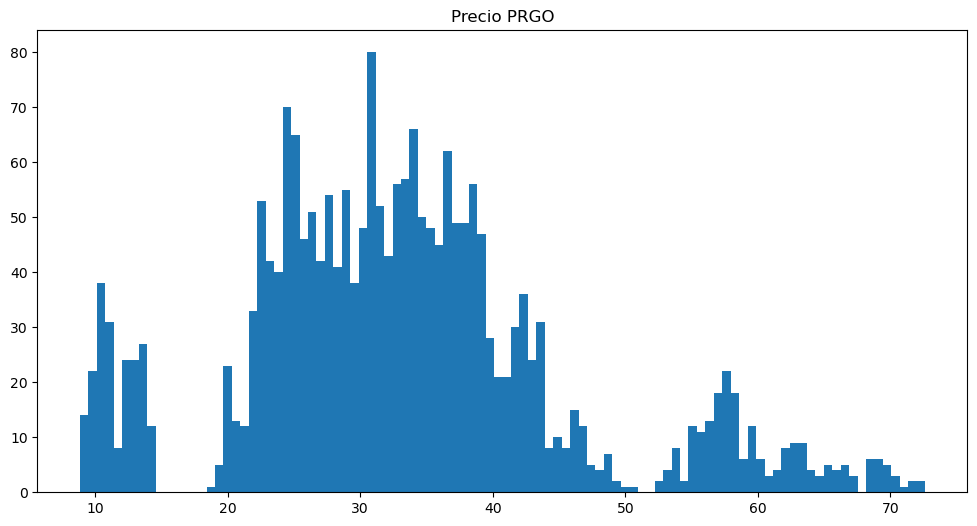

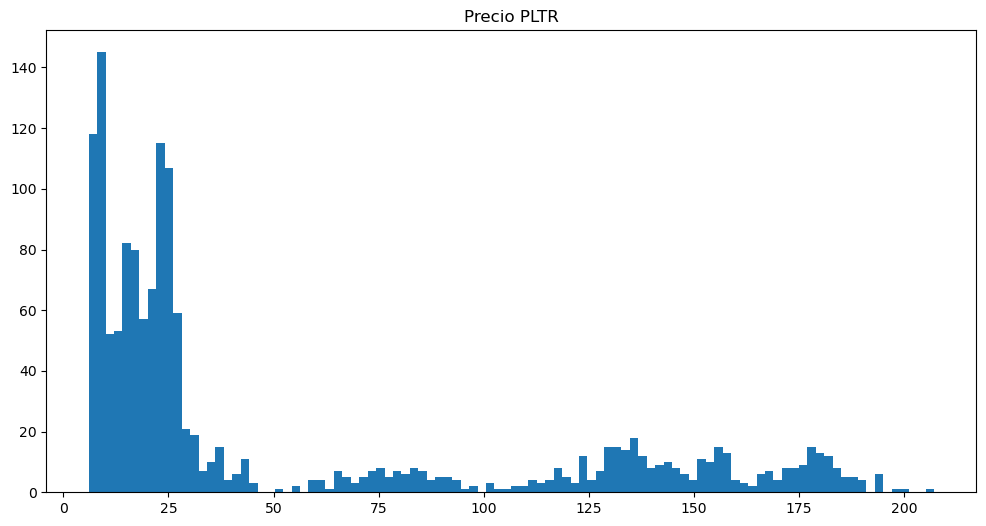

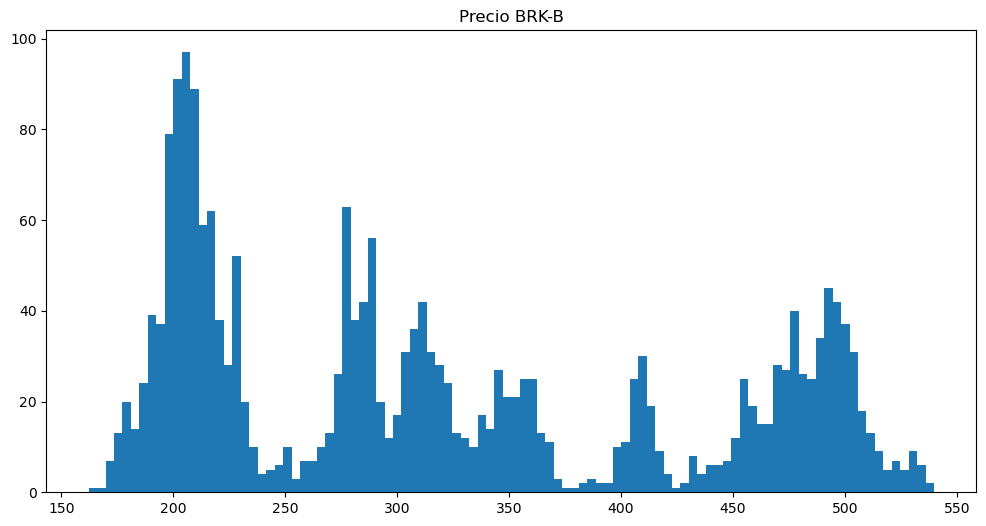

In [33]:
for i in tickers:
    plt.figure(figsize=(12, 6))
    plt.hist(prices[i], bins=100)
    plt.title(f'Precio {i}')
    plt.show(i)

## 3. Cálculo y Gráfica de la distribución de los rendimientos diarios 

In [34]:
daily_rets=prices/prices.shift()-1

In [35]:
daily_rets

Ticker,BRK-B,PLTR,PRGO
Date,,,
2018-01-02,NaN,NaN,NaN
2018-01-03,0.013031,NaN,-0.002787
2018-01-04,0.004505,NaN,0.018336
2018-01-05,0.003637,NaN,0.001098
2018-01-08,0.006554,NaN,-0.011516
...,...,...,...
2026-08-18,0.009494,-0.005853,0.011701
2026-08-19,-0.006641,0.021278,0.076330
2026-08-20,-0.005524,-0.007021,-0.018625


### Distribución de rendimientos diarios

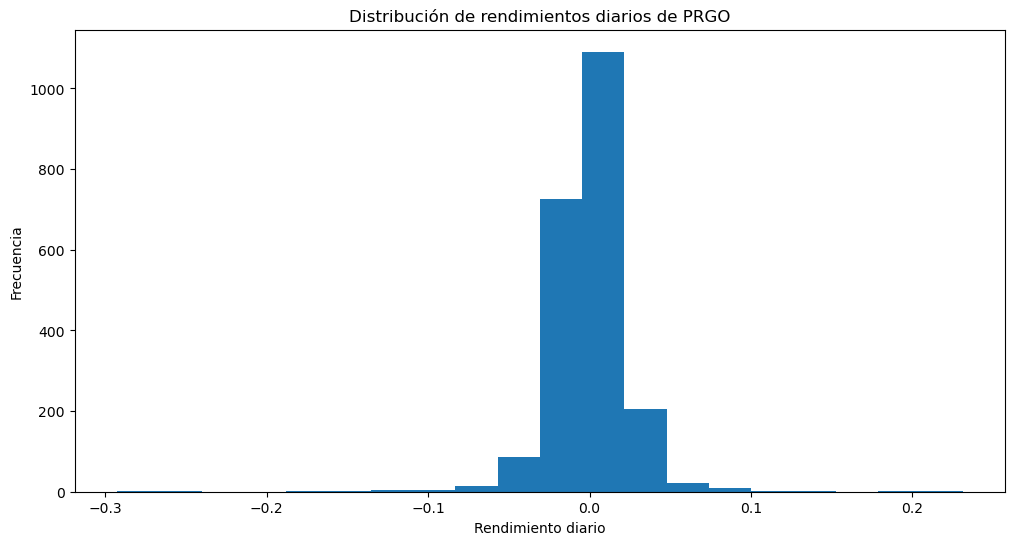

In [36]:
plt.figure(figsize=(12, 6))
plt.hist(daily_rets['PRGO'].dropna(), bins=20)
plt.title('Distribución de rendimientos diarios de PRGO')
plt.xlabel('Rendimiento diario')
plt.ylabel('Frecuencia')
plt.show()

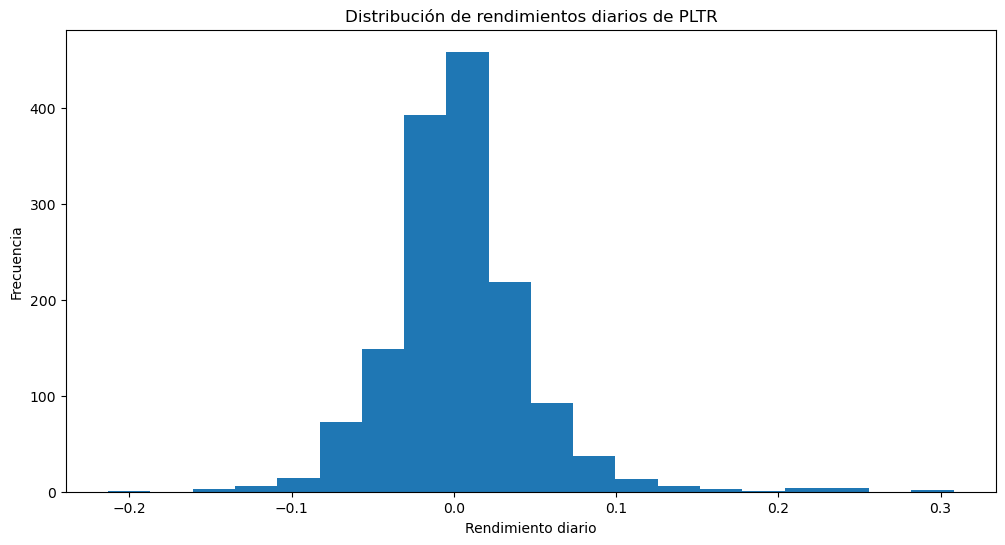

In [37]:
plt.figure(figsize=(12, 6))
plt.hist(daily_rets['PLTR'].dropna(), bins=20)
plt.title('Distribución de rendimientos diarios de PLTR')
plt.xlabel('Rendimiento diario')
plt.ylabel('Frecuencia')
plt.show()

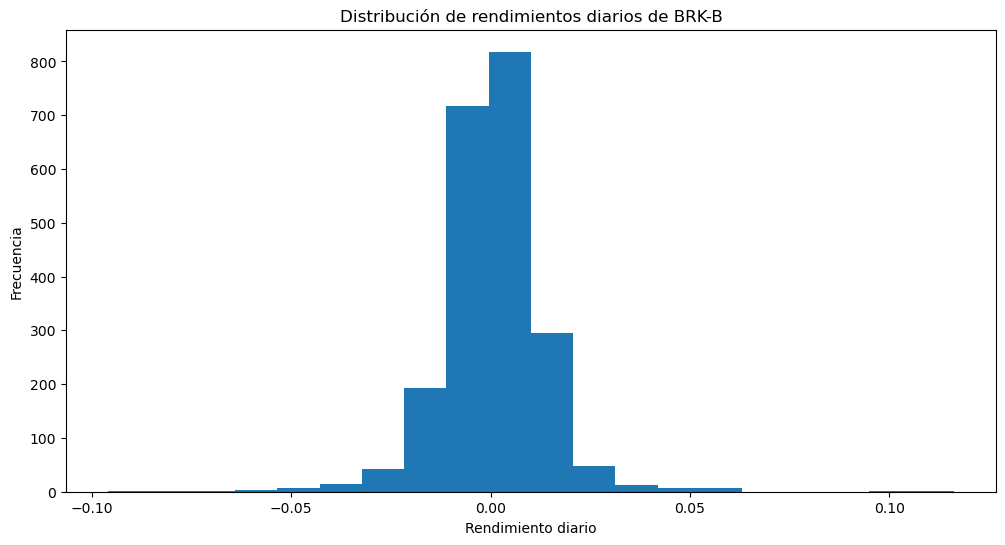

In [38]:
plt.figure(figsize=(12, 6))
plt.hist(daily_rets['BRK-B'].dropna(), bins=20)
plt.title('Distribución de rendimientos diarios de BRK-B')
plt.xlabel('Rendimiento diario')
plt.ylabel('Frecuencia')
plt.show()

## 4. Rendimiento promedio anual

In [39]:
daily_mean=daily_rets.mean()
daily_mean*100


Ticker
BRK-B    0.051528
PLTR     0.292680
PRGO    -0.042294
dtype: float64

In [40]:
annual_mean=daily_mean*252
annual_mean*100

Ticker
BRK-B    12.985014
PLTR     73.755343
PRGO    -10.658070
dtype: float64

En el periodo analizado, el activo que presenta un mayor rendimiento promedio anual es PLTR con 73.76%, seguido de BRK-B con 12.99%. Por otro lado, PRGO presenta un rendimiento promedio anual negativo de -10.66%, lo que indica que en promedio su comportamiento fue desfavorable para un inversionista.

## 5. Riesgo anual

### Varianza anual

In [41]:
daily_variance=daily_rets.var()
annual_variance=daily_variance*252
annual_variance*100

Ticker
BRK-B     4.165685
PLTR     49.463438
PRGO     15.162246
dtype: float64

Las unidades de la varianza no se pueden interpretar directamente   
por lo que se recomienda calcular la desviación estándar, que es la raíz cuadrada de la varianza.   
La desviación estándar nos da una idea de la dispersión de los datos y se puede interpretar en las mismas unidades que los datos originales.

### Volatilidad anual

In [42]:
daily_volatility=daily_rets.std()
daily_volatility*100

Ticker
BRK-B    1.285710
PLTR     4.430389
PRGO     2.452909
dtype: float64

In [43]:
volatility_annual=daily_volatility*np.sqrt(252)
volatility_annual*100

Ticker
BRK-B    20.410009
PLTR     70.330248
PRGO     38.938728
dtype: float64

La volatilidad nos indica qué tanto varían los rendimientos respecto a su media. En este caso, el activo con mayor volatilidad es PLTR con 70.33%, seguido de PRGO con 38.94%. Por otro lado, BRK-B presenta la menor volatilidad con 20.41%, por lo que es el activo más estable y menos riesgoso de los tres en términos de volatilidad.

### Coeficiente de Variación

In [44]:
CV=volatility_annual/annual_mean
CV

Ticker
BRK-B    1.571813
PLTR     0.953561
PRGO    -3.653450
dtype: float64

El coeficiente de variación permite comparar el riesgo en relación con el rendimiento promedio. Entre los activos que tienen rendimiento promedio positivo, PLTR presenta el menor CV con 0.95, seguido de BRK-B con 1.57, por lo que PLTR tiene una mejor relación entre riesgo y rendimiento. En el caso de PRGO, el CV es negativo porque su rendimiento promedio anual también es negativo, por lo que no se puede interpretar como que sea el mejor activo solo por tener el valor más bajo.

### Comparación de los activos

In [45]:
results= pd.DataFrame({
    'Rendimiento anual': annual_mean*100,
    'Volatilidad anual': volatility_annual*100,
    'CV': CV
})

results

,Rendimiento anual,Volatilidad anual,CV
Ticker,,,
BRK-B,12.985014,20.410009,1.571813
PLTR,73.755343,70.330248,0.953561
PRGO,-10.658070,38.938728,-3.653450


### ¿Qué activo es mejor?

Basándonos en estos resultados, consideramos que PLTR es el mejor activo, porque aunque tiene la volatilidad más alta, también tiene por mucho el rendimiento anual más alto y el menor CV entre los activos que tienen rendimiento positivo. Esto quiere decir que, en relación con el rendimiento que genera, su nivel de riesgo es mejor que el de BRK-B. En cambio, BRK-B es más estable pero tiene un rendimiento mucho menor, y PRGO no sería una buena opción porque tiene un rendimiento anual promedio negativo.


## 6. Asimetría

In [46]:
daily_rets.skew()

Ticker
BRK-B   -0.075664
PLTR     1.143028
PRGO    -0.977500
dtype: float64

Con estos resultados podemos interpretar:    
**1. BRK-B** tiene una asimetría casi = 0 (-0.07) por lo que su distribución pudiera ser casi simétrica aunque se inclina un poco mas a las perdidas.   
**2. PLTR** tiene una asimetría >0 por lo que es positiva (1.14) lo que indica que su distribución tiene una cola más larga hacia las ganancias y que pueden presentarse rendimientos positivos extremos.   
**3. PRGO** tiene una asimetría <0 negativa (-0.9775) por lo que hay una mayor posibilidad de que aparezcan pérdidas extremas que ganancias extremas

## 7. Conclusión final

Después de analizar el rendimiento, la volatilidad, el coeficiente de variación y la asimetría de los tres activos, consideramos que PLTR es el activo que presenta la mejor relación entre riesgo y rendimiento dentro de esta comparación. Aunque tiene la mayor volatilidad anual con 70.33%, también presenta el rendimiento promedio anual más alto con 73.76% y el menor coeficiente de variación entre los activos con rendimiento positivo, con 0.95.

Por otro lado, BRK-B es el activo más estable, ya que tiene la menor volatilidad anual con 20.41%, pero también presenta un rendimiento promedio anual mucho menor de 12.99%. En el caso de PRGO, su rendimiento promedio anual es negativo de -10.66%, por lo que no resulta atractivo dentro de esta comparación, aunque su coeficiente de variación también sea negativo.

La asimetría también refuerza nuestra decisión, ya que PLTR presenta una asimetría positiva de 1.14, lo que indica una cola más larga hacia las ganancias y la posibilidad de rendimientos positivos extremos. BRK-B presenta una distribución casi simétrica con una asimetría de -0.08, mientras que PRGO presenta una asimetría negativa de -0.98, mostrando una mayor presencia de rendimientos negativos extremos. Por estas razones, consideramos que PLTR es la mejor opción de los tres activos analizados, tomando en cuenta en conjunto el rendimiento, el riesgo y el comportamiento de su distribución.